# Tracking History

The `tools` package contains utilities that interact with the learning process itself. For example, `tools.lineage` has tools that track and plot lineages.

This document discusses the following components:

* `TrackParents` modifies the behaviour of an existing variator to also record lineages.

* `graph_lineage` takes a collection of individuals and plots their lineages, if recorded.

In [1]:
import random
random.seed(1)
from evokit.core import Population
from evokit.evolvables.bitstring import BitString, CountBits
from evokit.tools.lineage import TrackParents
from evokit.tools.lineage import graph_lineage

## Tracking Lineages

To enable lineage tracking, take an existing algorithm (e.g. [OneMax](./onemax.ipynb) with only crossover) and wrap its variator with `TrackParents`. Then, run the algorithm as normal.

In [2]:
T: int = 10

from evokit.evolvables.algorithms import SimpleLinearAlgorithm
from evokit.evolvables.bitstring import OnePointCrossover
from evokit.evolvables.selectors import TruncationSelector

another_pop = Population((BitString.random(size=20)
                          for _ in range(50)))

ctrl = SimpleLinearAlgorithm(another_pop,
                             CountBits(),
                             TruncationSelector(budget=6),
                             TrackParents(OnePointCrossover(0.5),
                                          max_parents=9))

for _ in range (10):
    ctrl.step()

## Accessing Parents

To record lineages, `TrackParents` stores the parents of each offspring in its `.parents`. The parents of these parents may also be recorded, forming a family graph.

In [3]:
ctrl.population[0].parents

(<evokit.evolvables.bitstring.BitString at 0x17fef3687d0>,
 <evokit.evolvables.bitstring.BitString at 0x17fef3689b0>)

Keeping track of parents costs memory: if an individual has at most $N$ parents and $K$ generations of parents are tracked, then at most

$$\sum^{K}_{i=1}{N^i}$$

extra individuals may be stored in memory. The cost can be significantly less in practice, as successful individuals often share common ancestors.

To limit the memory cost, EvoKit expunges an parent as long as soon it becomes the $k^\mathrm{th}$ ancestor of _any_ offspring. You can configure $k$ by supplying a different `max_parents` to `TrackParents`.

## Visualising Parents

The `graph_lineage` function takes a number of individuals and outputs a `Digraph` (type from the `graphviz` module). To view the graph, either render it in a notebook cell or export it by setting `save_as=<file_name_without_extension>`. The following cell does both.

In [4]:
dot = graph_lineage(ctrl.population,
                    use_colour=True,
                    compact=True,
                    save_as="./media/_temp-lineage")
dot

NameError: name 'Path' is not defined

## Prettify Output

Large individuals and long lineages can take up too much space. To remedy this, set `compact=True` to render individuals as dots. To view the string representation of a dot, export the diagram as SVG and view its tooltip.

Connections can look messy with large populations. If the compact view is not enough, increase vertical spacing with `vertical_spacing=<N>`.

<img src='media\lineage-tooltip.png' style='width: 15em'></img>

Before closing the tutorial, let's see a graph without all the nicities:

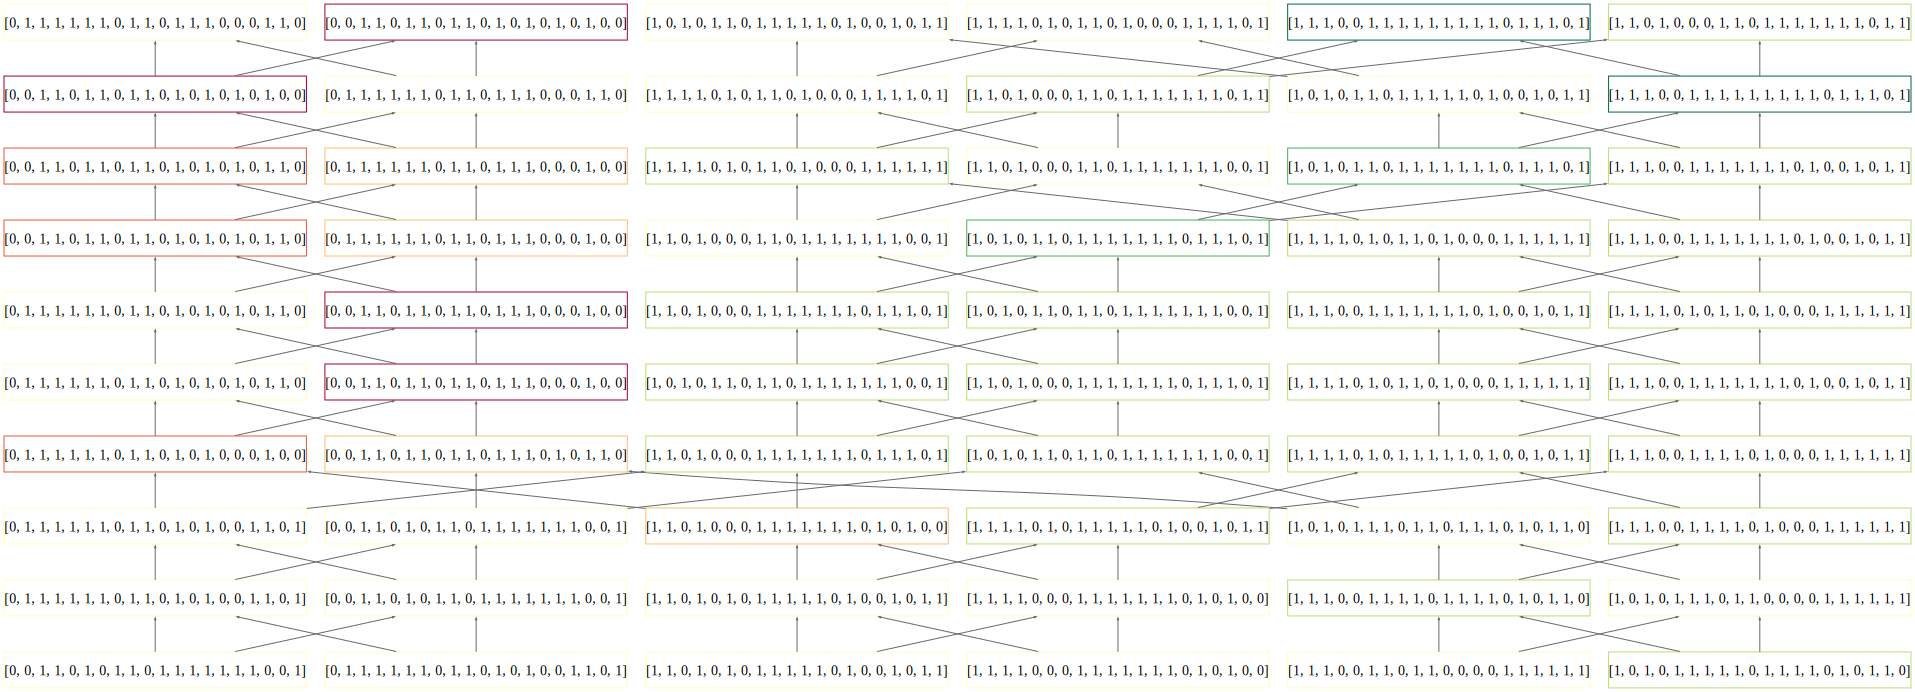

In [ ]:
dot = graph_lineage(ctrl.population,
                    compact=False,)
dot